In [1]:
import re
import pandas as pd
from pathlib import Path


In [2]:
# ===== patterns =====

outer_re = re.compile(r"^=+\s*Outer Iteration\s+(\d+)\s*/\s*(\d+)\s*=+")

# Example:
# [HAM] step   10 | loss=7.945e-04 | grad=3.65e-03 | Δ=-1.50997 h=-0.29001 |
ham_re = re.compile(
    r"\[HAM\]\s*step\s*(\d+)\s*\|"
    r".*?\bloss=([0-9.+-eE]+)\b"
    r".*?\|\s*(?:Δ|delta|Delta)\s*=\s*([0-9.+-eE]+)\b"
    r"\s*h\s*=\s*([0-9.+-eE]+)\b"
)


In [21]:
file_path = Path("./xxz_dmrg_active_403138.out")

rows = []

outer_iter = None
outer_total = None

with file_path.open("r", encoding="utf-8", errors="replace") as f:
    for line in f:

        # outer iteration
        m_outer = outer_re.match(line)
        if m_outer:
            outer_iter = int(m_outer.group(1))
            outer_total = int(m_outer.group(2))
            continue

        # HAM optimization line
        m = ham_re.search(line)
        if m:
            step = int(m.group(1))
            loss = float(m.group(2))
            delta = float(m.group(3))
            h = float(m.group(4))

            rows.append({
                "outer_iter": outer_iter,
                "outer_total": outer_total,
                "step": step,
                "loss": loss,
                "delta": delta,
                "h": h,
            })


In [22]:
df = pd.DataFrame(rows)
df.head()


,outer_iter,outer_total,step,loss,delta,h
0,1,6,1,0.000833,-1.50100,-0.29900
1,1,6,10,0.000794,-1.50997,-0.29001
2,1,6,20,0.000753,-1.51979,-0.28009
3,1,6,30,0.000714,-1.52934,-0.27028
4,1,6,40,0.000678,-1.53856,-0.26061


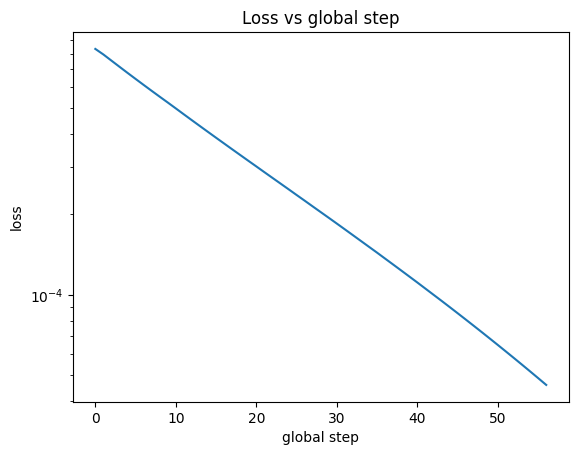

In [23]:
import matplotlib.pyplot as plt

df = df.copy()
df["global_step"] = range(len(df))

plt.figure()
plt.plot(df["global_step"], df["loss"])
plt.yscale("log")
plt.xlabel("global step")
plt.ylabel("loss")
plt.title("Loss vs global step")
plt.show()



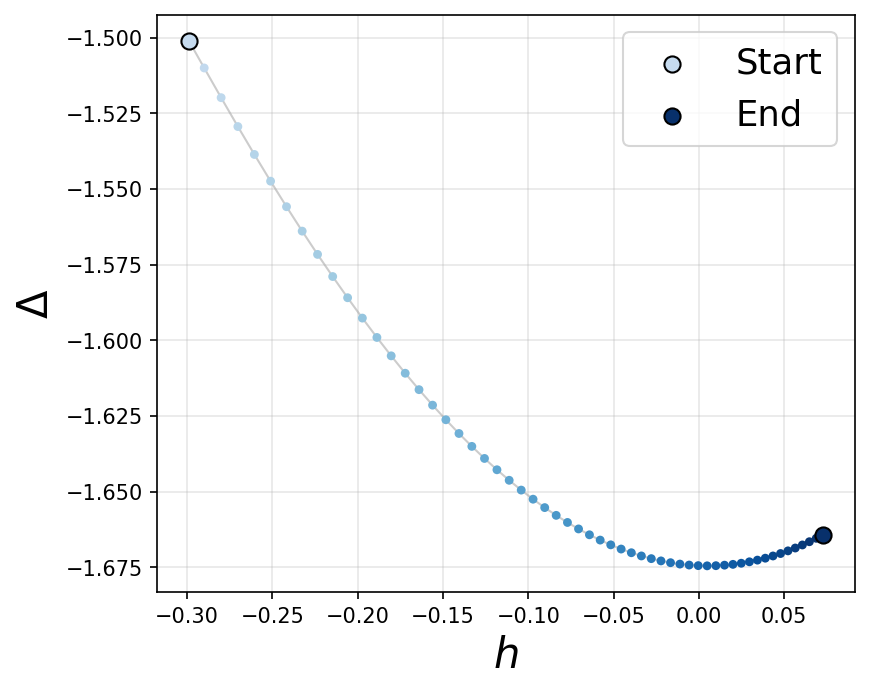

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# NEW: take delta/h from the parsed output dataframe
# df must have columns: "delta", "h"
deltas = df["delta"].to_numpy()
hs     = df["h"].to_numpy()

n = len(hs)
order = np.arange(n)  # 0 ... n-1 (time)

fig, ax = plt.subplots(figsize=(6,5), dpi=150)

# light-to-dark shades of one hue (same color, different shade)
cmap = plt.cm.Blues
shades = cmap(np.linspace(0.25, 1.0, n))  # start light, end dark

# optional: faint line to show trajectory
ax.plot(hs, deltas, lw=1.0, color='0.5', alpha=0.4, zorder=1)

# points colored by shade
ax.scatter(hs, deltas, c=shades, s=18, edgecolors='none', zorder=2)

# emphasize start/end
ax.scatter(hs[0],  deltas[0],  s=60, color=shades[0],  edgecolors='k', zorder=3, label="Start")
ax.scatter(hs[-1], deltas[-1], s=60, color=shades[-1], edgecolors='k', zorder=3, label="End")

ax.set_xlabel(r"$h$", fontsize=20)
ax.set_ylabel(r"$\Delta$", fontsize=20)

# ax.set_yticks([-1.6, -1.4, -1.2, -1.0, -0.8, -0.6])
# ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
# ax.set_xticklabels([0.1, 0.2, 0.3, 0.4, 0.5, 0.6], fontsize=16)
# ax.set_yticklabels([-1.6, -1.4, -1.2, -1.0, -0.8, -0.6], fontsize=16)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=17)

# plt.tight_layout()
# plt.savefig(f"../figures/{file_name}.pdf", bbox_inches="tight")
plt.show()
